<h1 style="color:red;">Importing libraries</h1>

In [1]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import torch
import warnings
warnings.filterwarnings('ignore')

C:\Users\USER\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h1 style="color:red;">Dataset and Preprocessing</h1>

In [2]:
df = pd.read_csv('Data/reddit_depression_dataset.csv')

In [3]:
df

,Unnamed: 0,subreddit,title,body,upvotes,created_utc,num_comments,label
0,47951,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4.0,1.405309e+09,NaN,0.0
1,47952,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4.0,1.410568e+09,1.0,0.0
2,47957,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6.0,1.416458e+09,1.0,0.0
3,47959,DeepThoughts,"""I want to be like water. I want to slip throu...",NaN,25.0,1.416512e+09,2.0,0.0
4,47960,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5.0,1.416516e+09,4.0,0.0
...,...,...,...,...,...,...,...,...
2470773,10742224,depression,Alone as usual,I just argued with my mom an hour ago; she alw...,9.0,1.672529e+09,6.0,1.0
2470774,10742230,depression,Help needed urgently!,OK basically non of my friend's or family invi...,5.0,1.672530e+09,7.0,1.0
2470775,10742232,depression,I know what your thinking,Don't do It. Not today. Its gonna be ok if you...,10.0,1.672530e+09,8.0,1.0
2470776,10742243,depression,how do I stop having such a cynical view on ma...,"So I don't know, I've recently realized that t...",8.0,1.672531e+09,9.0,1.0


In [6]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470778 entries, 0 to 2470777
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Unnamed: 0    object 
 1   subreddit     object 
 2   title         object 
 3   body          object 
 4   upvotes       float64
 5   created_utc   float64
 6   num_comments  float64
 7   label         float64
dtypes: float64(4), object(4)
memory usage: 150.8+ MB


In [7]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Unnamed: 0,subreddit,title,body,upvotes,created_utc,num_comments,label
0,47951,DeepThoughts,Deep thoughts underdog,"Only when we start considering ourselves, the ...",4.0,1.405309e+09,NaN,0.0
1,47952,DeepThoughts,"I like this sub, there's only two posts yet I ...",Anyway: Human Morality is a joke so long as th...,4.0,1.410568e+09,1.0,0.0
2,47957,DeepThoughts,Rebirth!,Hello. \nI am the new guy in charge here (Besi...,6.0,1.416458e+09,1.0,0.0
3,47959,DeepThoughts,"""I want to be like water. I want to slip throu...",NaN,25.0,1.416512e+09,2.0,0.0
4,47960,DeepThoughts,Who am I?,You could take any one cell in my body and kil...,5.0,1.416516e+09,4.0,0.0


In [8]:
df = df.drop(columns=['created_utc'])
df = df.drop(columns=['subreddit'])
df = df.drop(columns=['Unnamed: 0'])

In [9]:
df = df.dropna(subset=['title', 'body', 'upvotes', 'num_comments', 'label']).reset_index(drop=True)

df['upvotes'] = pd.to_numeric(df['upvotes'], errors='coerce')
df['num_comments'] = pd.to_numeric(df['num_comments'], errors='coerce')

df = df.dropna(subset=['upvotes', 'num_comments']).reset_index(drop=True)

df['upvotes'] = df['upvotes'].astype(int)
df['num_comments'] = df['num_comments'].astype(int)

df['text'] = df['title'] + ' ' + df['body']

def clean_text(text):
    text = re.sub(r'http\S+', '', text)             
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text) 
    text = re.sub(r'\n|\t|\r', ' ', text)           
    text = re.sub(r'\d+', '', text)                    
    text = re.sub(r'[^A-Za-z\s]', '', text)           
    text = text.lower()                              
    text = re.sub(r'\s+', ' ', text).strip()          
    return text

df['text'] = df['text'].apply(clean_text)
df = df.drop(columns=['title'])
df = df.drop(columns=['body'])

print("Shape after full cleaning:", df.shape)
df[['text', 'upvotes', 'num_comments', 'label']].head()

Shape after full cleaning: (1925427, 4)


,text,upvotes,num_comments,label
0,i like this sub theres only two posts yet i ke...,4,1,0.0
1,rebirth hello i am the new guy in charge here ...,6,1,0.0
2,who am i you could take any one cell in my bod...,5,4,0.0
3,what is the limit of the knowledge and power a...,8,23,0.0
4,bits contest changetip hello from now to chris...,7,26,0.0


In [10]:
df.isnull().sum()

upvotes         0
num_comments    0
label           0
text            0
dtype: int64

In [12]:
df.to_csv('Data/cleaned_reddit_data.csv', index=False)

print("file saved 'cleaned_reddit_data.csv'.")

file saved 'cleaned_reddit_data.csv'.


In [11]:
print("🔵 Distribution of Labels:")
df['label'].value_counts()

🔵 Distribution of Labels:


label
0.0    1499842
1.0     425585
Name: count, dtype: int64

In [13]:
df_majority = df[df['label'] == 0]
df_minority = df[df['label'] == 1]

df_majority_undersampled = df_majority.sample(n=len(df_minority), random_state=42)

df_balanced = pd.concat([df_majority_undersampled, df_minority], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['label'].value_counts())
print(df_balanced.shape)

label
0.0    425585
1.0    425585
Name: count, dtype: int64
(851170, 4)


In [14]:
df = df.sample(frac=1).reset_index(drop=True)

In [15]:
df_balanced.to_csv('Data/balanced_reddit_data.csv', index=False)

print("file saved 'cleaned_reddit_data.csv'.")

file saved 'cleaned_reddit_data.csv'.


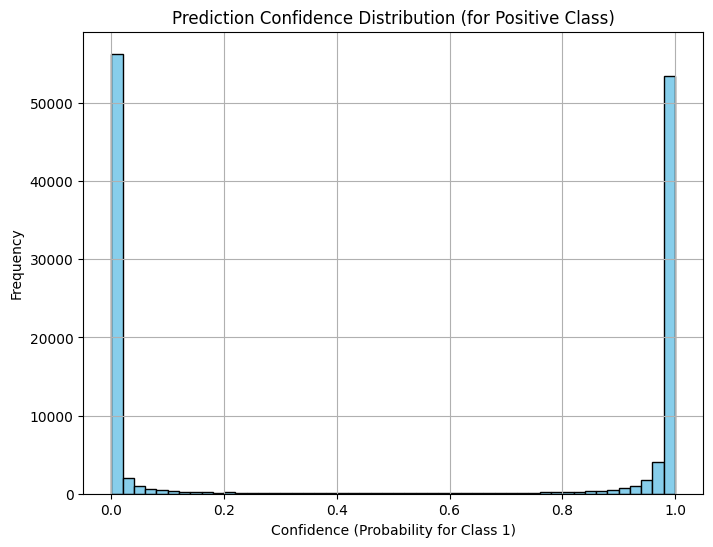

In [24]:
def plot_prediction_confidence(probs_list):
    plt.figure(figsize=(8,6))
    plt.hist(probs_list, bins=50, color='skyblue', edgecolor='black')
    plt.title('Prediction Confidence Distribution (for Positive Class)')
    plt.xlabel('Confidence (Probability for Class 1)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

plot_prediction_confidence(all_probs)